In [6]:
# ⛳ COLAB SETUP — RUN THIS FIRST


import os

# Keep versions compatible with umap-learn: scikit-learn 1.6.1
!pip -q install --upgrade pip
!pip -q install \
  plotnine==0.13.6 \
  plotly==5.23.0 \
  yfinance==0.2.50 \
  kaleido==0.2.1 \
  scikit-learn==1.6.1 \
  "pandas>=2.2.2" \
  "matplotlib>=3.8.4"

DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)
print("📁 DATA_DIR =", DATA_DIR)

def data_path(filename: str) -> str:
    """Resolve inside DATA_DIR by default; fall back to CWD and /content if needed."""
    candidates = [
        os.path.join(DATA_DIR, filename),
        os.path.join(os.getcwd(), filename),
        os.path.join("/content", filename),
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    return candidates[0]

def list_data():
    print("📦 Files in DATA_DIR:")
    for name in sorted(os.listdir(DATA_DIR)):
        print(" -", name)


📁 DATA_DIR = /content/data


In [7]:
# 📤 LOCAL FILE UPLOAD — RUN THIS TO SELECT FILES FROM YOUR COMPUTER
# A file picker will open. You can multi-select. Files go to /content/data.

from google.colab import files  # type: ignore
import os

print("➡️ Select your local files (you can multi-select).")
uploaded = files.upload()  # opens the file picker

# Save bytes into DATA_DIR
saved = []
for fname, content in uploaded.items():
    dst = os.path.join(DATA_DIR, os.path.basename(fname))
    with open(dst, "wb") as f:
        f.write(content)  # content is raw bytes
    saved.append(dst)

print("\n✅ Saved:")
for s in saved:
    print(" -", s)

print("\nTip: if you need to add more files, RUN THIS CELL AGAIN.")
list_data()

# Optional heads-up for later exercises:
need = ["Airlines.csv", "Airline_Delay_Cause.csv"]
missing = [n for n in need if not os.path.exists(os.path.join(DATA_DIR, n))]
if missing:
    print("\n⚠️ Recommended files not found yet:", ", ".join(missing))
    print("   Upload them now (rename to these exact names if needed).")
else:
    print("\n✅ Required example files detected: Airlines.csv, Airline_Delay_Cause.csv")


➡️ Select your local files (you can multi-select).


Saving Airline_Delay_Cause.csv to Airline_Delay_Cause.csv
Saving Airlines.csv to Airlines.csv
Saving combined_final_last_10_years.csv to combined_final_last_10_years.csv
Saving continent_country.csv to continent_country.csv
Saving demox_eiu.csv to demox_eiu.csv
Saving Download_Column_Definitions.xlsx to Download_Column_Definitions.xlsx
Saving gini.csv to gini.csv
Saving income_per_person_gdppercapita_ppp_inflation_adjusted.csv to income_per_person_gdppercapita_ppp_inflation_adjusted.csv
Saving investments_percent_of_gdp.csv to investments_percent_of_gdp.csv
Saving tax_revenue_percent_of_gdp.csv to tax_revenue_percent_of_gdp.csv

✅ Saved:
 - /content/data/Airline_Delay_Cause.csv
 - /content/data/Airlines.csv
 - /content/data/combined_final_last_10_years.csv
 - /content/data/continent_country.csv
 - /content/data/demox_eiu.csv
 - /content/data/Download_Column_Definitions.xlsx
 - /content/data/gini.csv
 - /content/data/income_per_person_gdppercapita_ppp_inflation_adjusted.csv
 - /content/

In [8]:
# Common imports & helpers (English-only comments/labels)
import os, math, json
import pandas as pd
import numpy as np
from plotnine import (
    ggplot, aes, geom_point, geom_bar, labs, theme_minimal, facet_wrap,
    position_stack, theme, element_text, scale_color_brewer
)
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# Matplotlib inline + toolbar (zoom/pan)
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

def smart_read_csv(candidates):
    """Return the first readable CSV among candidates, or None."""
    for path in candidates:
        if path and os.path.exists(path):
            try:
                return pd.read_csv(path)
            except Exception:
                pass
    return None

def find_col(df, candidates):
    """Find a column in df matching any candidate (case-insensitive)."""
    for c in candidates:
        if c in df.columns: return c
    lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower: return lower[c.lower()]
    return None

print("✅ Imports ready.")


✅ Imports ready.


## Exercise 1 — Scatter plot with aesthetic mappings (plotnine)
**Objective:** Create a scatter using `geom_point()` mapping `x`, `y`, and `color`.


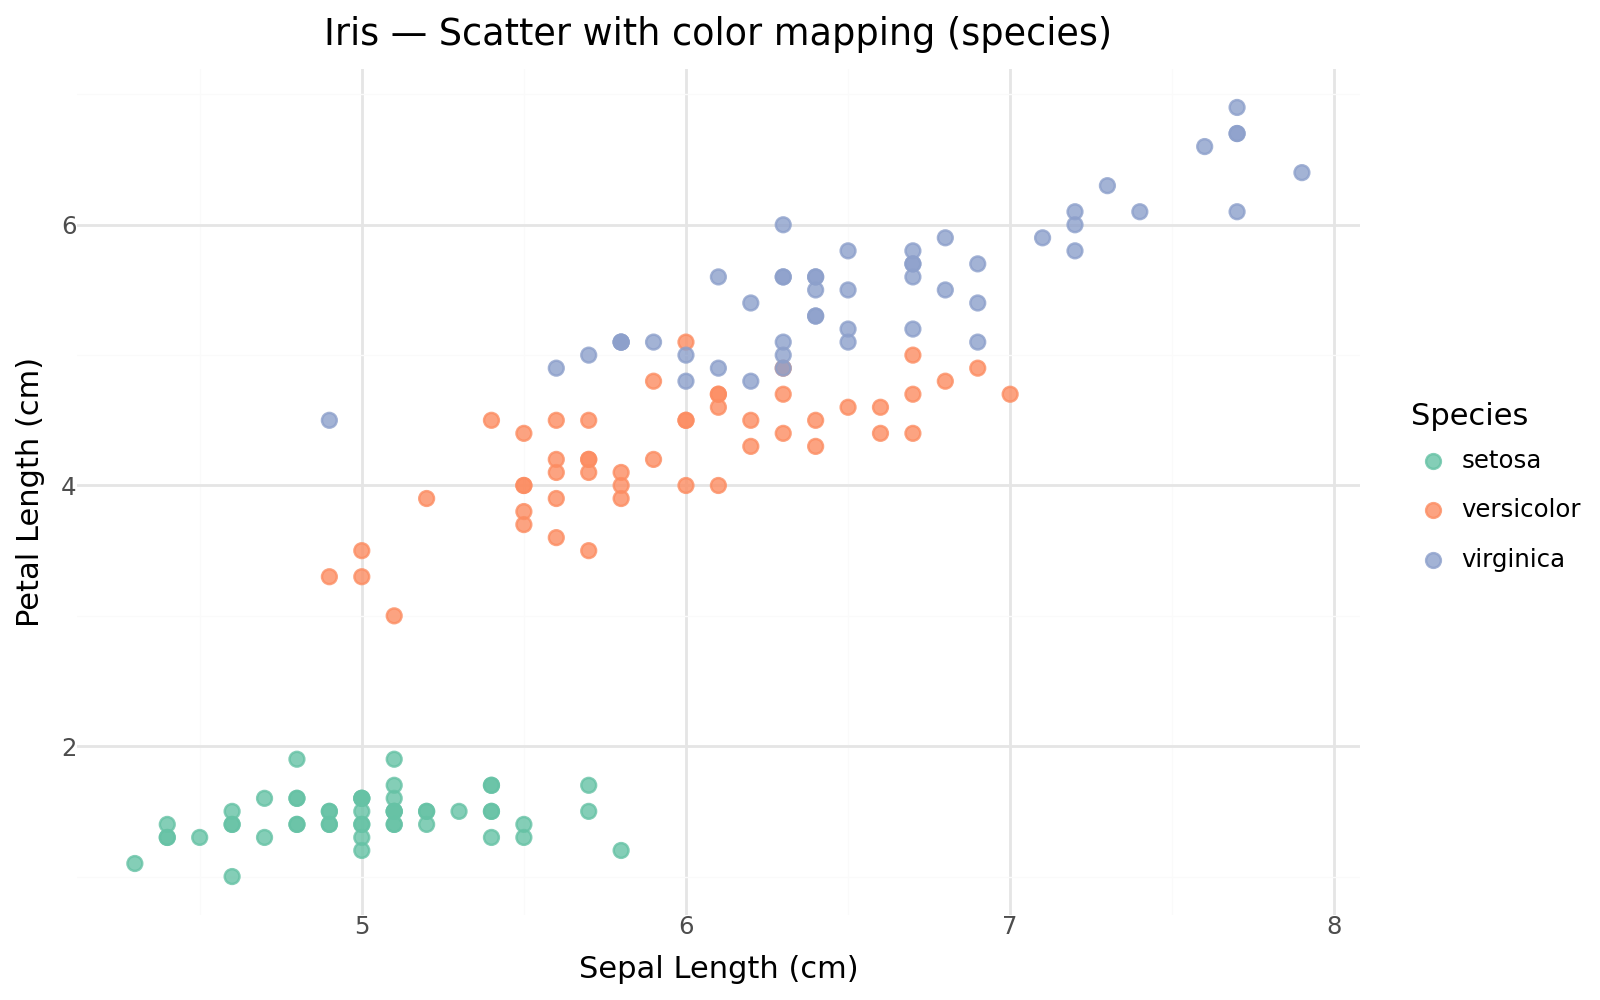

In [10]:
from sklearn.datasets import load_iris
iris_raw = load_iris(as_frame=True)
iris = iris_raw.frame.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width",
})
iris["species"] = iris_raw.target_names[iris_raw.target]

p1 = (
    ggplot(iris, aes(x="sepal_length", y="petal_length", color="species"))
    + geom_point(alpha=0.8, size=2.5)
    + scale_color_brewer(type="qual", palette="Set2")
    + labs(title="Iris — Scatter with color mapping (species)",
           x="Sepal Length (cm)", y="Petal Length (cm)", color="Species")
    + theme_minimal()
    + theme(figure_size=(8,5), axis_text_x=element_text(rotation=0))
)
p1


## Exercise 2 — Stacked bar chart (plotnine)
**Objective:** Stacked bars: `x` = categorical variable, `fill` = another category.


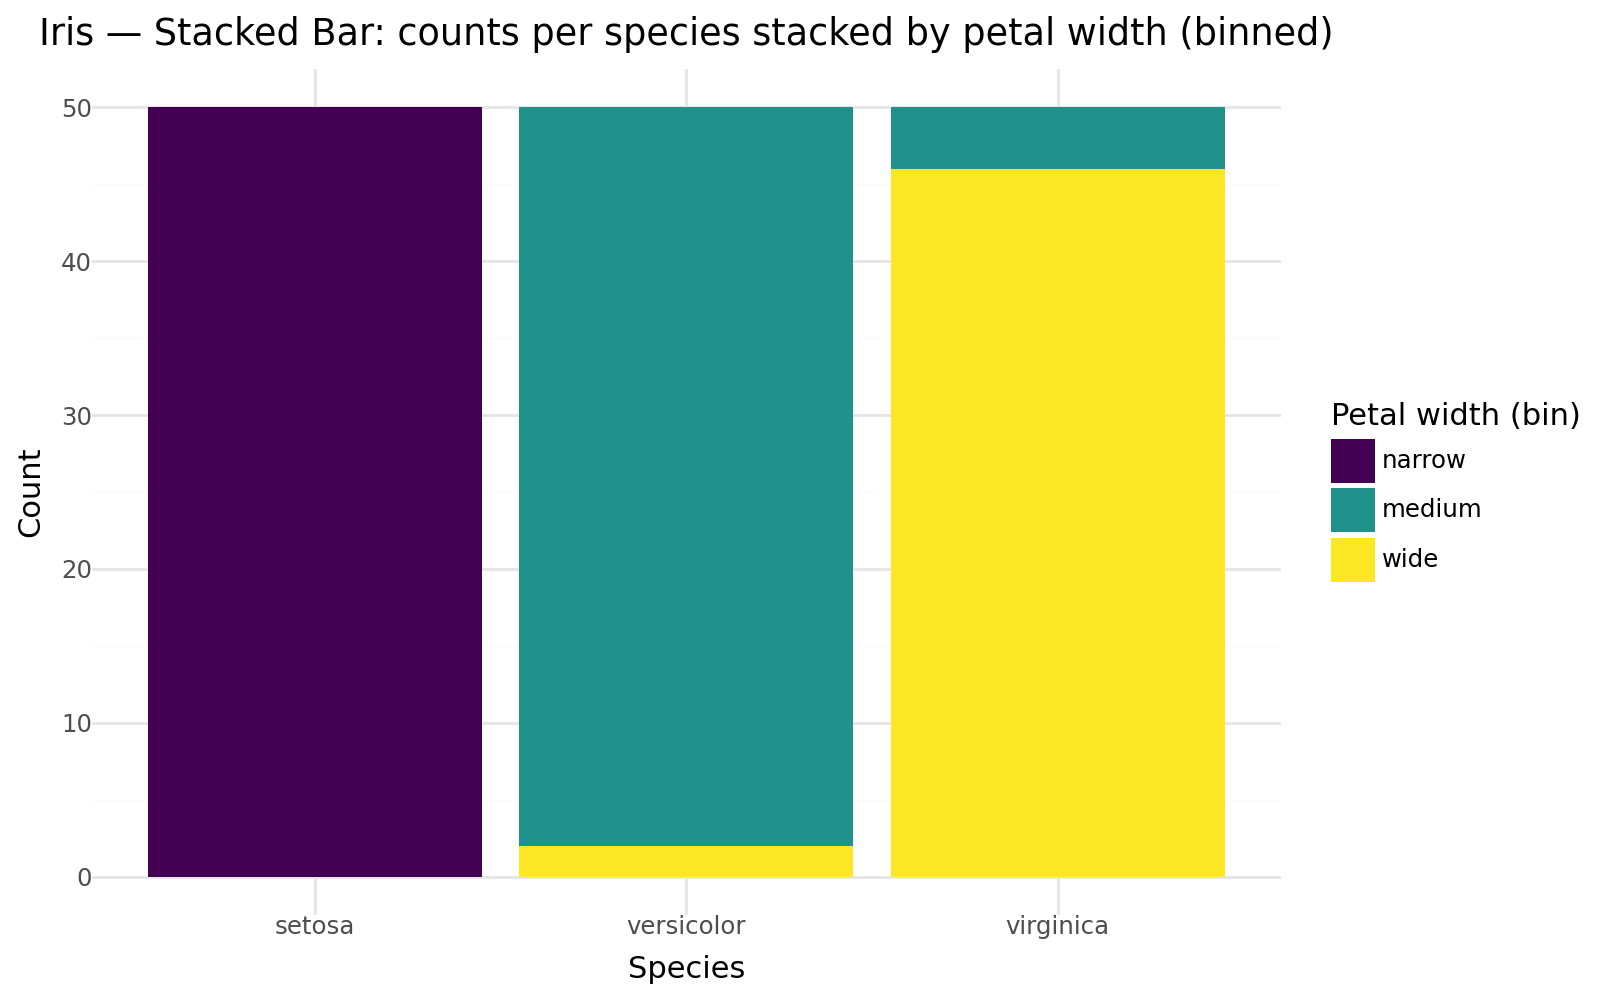

In [11]:
# Create a binned category for stacking (petal width terciles)
bins = pd.qcut(iris["petal_width"], q=3, labels=["narrow", "medium", "wide"])
iris2 = iris.copy()
iris2["petal_width_bin"] = bins

p2 = (
    ggplot(iris2, aes(x="species", fill="petal_width_bin"))
    + geom_bar(position="stack")
    + labs(title="Iris — Stacked Bar: counts per species stacked by petal width (binned)",
           x="Species", y="Count", fill="Petal width (bin)")
    + theme_minimal()
    + theme(figure_size=(8,5))
)
p2


## Exercise 3 — Facet wrapping (plotnine)
**Objective:** Create multiple panels by `species` using `facet_wrap()`.


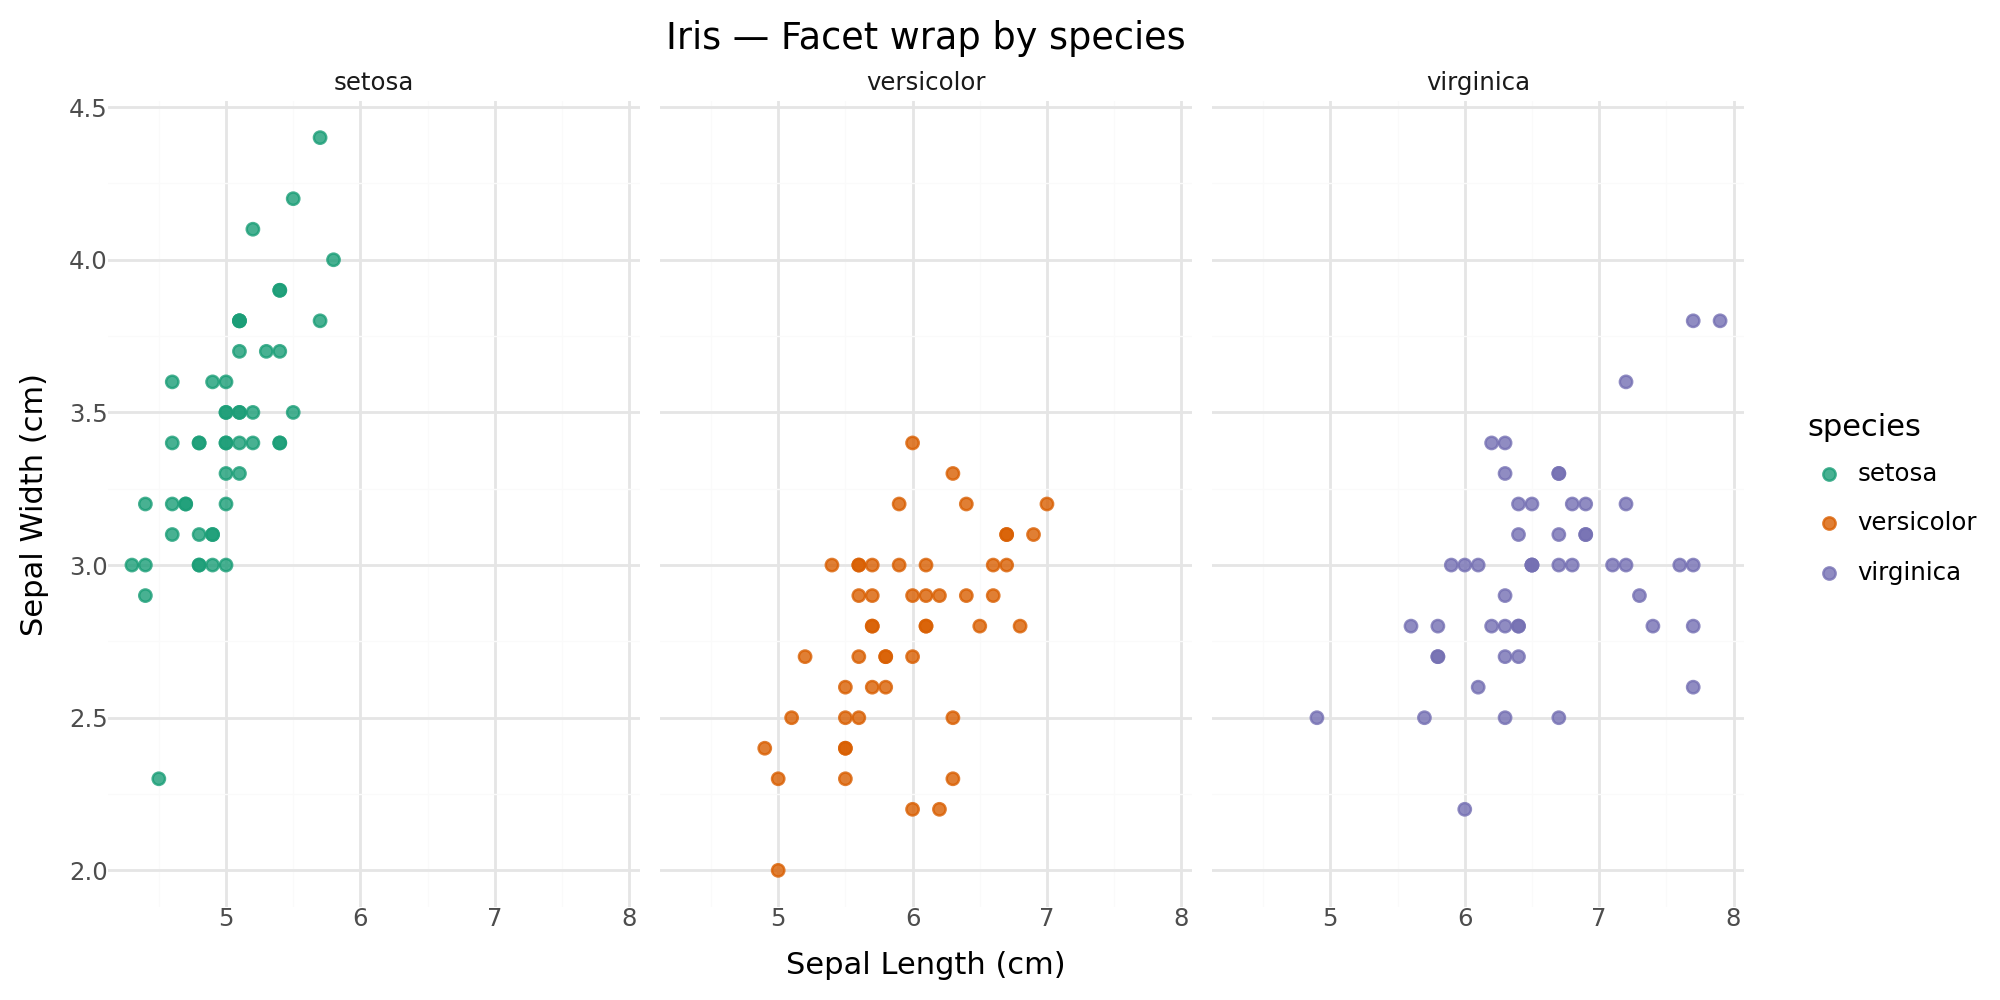

In [12]:
p3 = (
    ggplot(iris, aes(x="sepal_length", y="sepal_width", color="species"))
    + geom_point(alpha=0.8, size=2)
    + facet_wrap("~species")
    + scale_color_brewer(type="qual", palette="Dark2")
    + labs(title="Iris — Facet wrap by species",
           x="Sepal Length (cm)", y="Sepal Width (cm)")
    + theme_minimal()
    + theme(figure_size=(10,5))
)
p3


## Exercise 4 — Interactive line chart (Plotly + Gapminder)
**Objective:** Interactive GDP per capita over time for a selected country.


In [13]:
gap = px.data.gapminder()
countries = sorted(gap["country"].unique().tolist())
default_country = "Israel" if "Israel" in countries else countries[0]

def line_for(country):
    df = gap[gap["country"] == country].sort_values("year")
    fig = px.line(
        df, x="year", y="gdpPercap", markers=True,
        title=f"GDP per capita over time — {country}",
        labels={"year": "Year", "gdpPercap": "GDP per capita (USD, inflation-adjusted)"}
    )
    fig.update_layout(hovermode="x unified")
    return fig

fig4 = line_for(default_country)
fig4.update_layout(
    updatemenus=[dict(
        buttons=[dict(
            method="update",
            label=c,
            args=[{"x":[gap[gap['country']==c].sort_values('year')["year"]],
                   "y":[gap[gap['country']==c].sort_values('year')["gdpPercap"]]},
                  {"title": f"GDP per capita over time — {c}"}]
        ) for c in countries[:20]],  # limit to 20 for readability
        direction="down", x=0.0, y=1.2
    )]
)
fig4


## Exercise 5 — 3D scatter (Plotly) with Iris
**Objective:** Visualize `sepal_length`, `sepal_width`, `petal_length` in 3D; color by `species`.


In [14]:
fig5 = px.scatter_3d(
    iris, x="sepal_length", y="sepal_width", z="petal_length",
    color="species", hover_name="species",
    title="Iris — 3D Scatter (sepal length / sepal width / petal length)",
    labels={"sepal_length":"Sepal Length", "sepal_width":"Sepal Width", "petal_length":"Petal Length"}
)
fig5.update_traces(marker=dict(size=4, opacity=0.85))
fig5


## Exercise 6 — Interactive heatmap (Plotly) — Flight frequency between US cities
**Objective:** Heatmap on `origin_city × dest_city`, intensity = number of flights.


In [15]:
airlines_path = data_path("Airlines.csv")
df_air = None
if os.path.exists(airlines_path):
    try:
        df_air = pd.read_csv(airlines_path)
    except Exception as e:
        print("Reading Airlines.csv failed:", e)

if df_air is not None and {"ORIGIN_CITY_NAME","DEST_CITY_NAME"}.issubset(df_air.columns):
    freq = (df_air.groupby(["ORIGIN_CITY_NAME","DEST_CITY_NAME"])
                  .size().reset_index(name="flights"))
    # Keep top 10 origins/dests for readability
    top_orig = freq.groupby("ORIGIN_CITY_NAME")["flights"].sum().nlargest(10).index
    top_dest = freq.groupby("DEST_CITY_NAME")["flights"].sum().nlargest(10).index
    freq2 = freq[freq["ORIGIN_CITY_NAME"].isin(top_orig) & freq["DEST_CITY_NAME"].isin(top_dest)]
    pivot = freq2.pivot(index="DEST_CITY_NAME", columns="ORIGIN_CITY_NAME", values="flights").fillna(0)
else:
    # Synthetic fallback if file/columns are missing
    data = {
        "ORIGIN_CITY_NAME": ["New York","New York","Los Angeles","Chicago","Dallas","Atlanta","Miami","San Francisco"]*4,
        "DEST_CITY_NAME":   ["Chicago","Atlanta","New York","Dallas","Los Angeles","Miami","San Francisco","Dallas"]*4,
    }
    tmp = pd.DataFrame(data)
    freq = tmp.groupby(["ORIGIN_CITY_NAME","DEST_CITY_NAME"]).size().reset_index(name="flights")
    pivot = freq.pivot(index="DEST_CITY_NAME", columns="ORIGIN_CITY_NAME", values="flights").fillna(0)

fig6 = go.Figure(data=go.Heatmap(
    z=pivot.values,
    x=pivot.columns.tolist(),
    y=pivot.index.tolist(),
    hoverongaps=False,
    coloraxis="coloraxis"
))
fig6.update_layout(
    title="Flight frequency heatmap (US cities)",
    xaxis_title="Departure City",
    yaxis_title="Arrival City",
    coloraxis=dict(colorscale="Viridis")
)
fig6


## Exercise 7 — Large time series with Matplotlib (stock index over 10 years)
**Objective:** Download via **yfinance** (S&P 500 — ticker `^GSPC`) and plot `Close`.
Resample monthly for efficiency; pan/zoom via the Matplotlib toolbar.


/tmp/ipython-input-3933152219.py:147: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



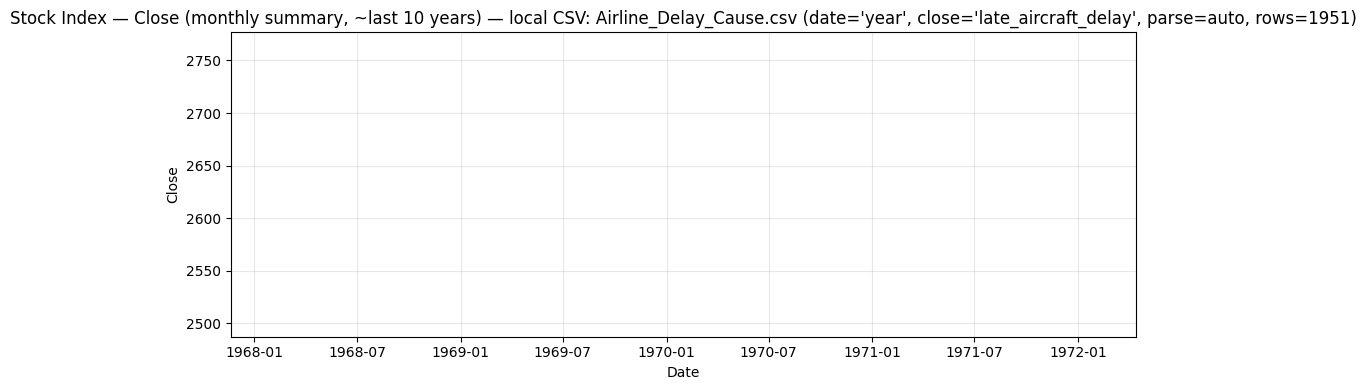

✅ Using local file: /content/data/Airline_Delay_Cause.csv
✔️ Done.


In [19]:
# Exercise 7 — Large time series with Matplotlib (robust CSV detection + graceful fallbacks)
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yfinance as yf
except Exception:
    yf = None  # yfinance optional if offline

# ---------- Helpers ----------
DATE_FORMATS = [
    "%Y-%m-%d", "%d/%m/%Y", "%m/%d/%Y",
    "%Y/%m/%d", "%d-%m-%Y", "%m-%d-%Y",
    "%d.%m.%Y", "%Y.%m.%d"
]
DATE_HINTS   = ["date", "time", "timestamp", "datetime"]
CLOSE_HINTS  = ["close", "adj close", "adjclose", "close price",
                "closing", "closeprice", "last", "price", "adj_close"]

def _norm(s: str) -> str:
    s = str(s)
    s = s.strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^a-z0-9 _-]", "", s)
    return s

def find_col(df: pd.DataFrame, hints) -> str | None:
    nm = {c: _norm(c) for c in df.columns}
    # direct contains any hint
    for c in df.columns:
        n = nm[c]
        if any(h in n for h in hints):
            return c
    # try exacts after norm (rare cases)
    for c in df.columns:
        n = nm[c]
        if n in hints:
            return c
    return None

def parse_dates_with_best_format(series: pd.Series):
    """Try multiple formats and pick the one with most valid rows; fallback to pandas auto."""
    best = None
    best_valid = -1
    for fmt in DATE_FORMATS:
        parsed = pd.to_datetime(series, errors="coerce", format=fmt)
        valid = parsed.notna().sum()
        if valid > best_valid:
            best_valid = valid
            best = parsed
    if best_valid >= max(5, int(0.4 * len(series))):  # at least 40% parse success or >=5 rows
        return best, "explicit"
    # fallback to pandas auto (may warn; we’ll silence it)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        auto = pd.to_datetime(series, errors="coerce", infer_datetime_format=True)
    return auto, "auto"

def detect_series_from_df(df: pd.DataFrame):
    # candidate columns
    date_col = find_col(df, DATE_HINTS) or df.columns[0]
    close_col = find_col(df, CLOSE_HINTS)
    if close_col is None:
        # heuristic: pick the last numeric column if nothing matched
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        close_col = num_cols[-1] if num_cols else None
    if date_col is None or close_col is None:
        return None, None, None, None, None

    # parse dates robustly
    parsed_dates, mode = parse_dates_with_best_format(df[date_col])
    tmp = pd.DataFrame({
        "dt": parsed_dates,
        "close": pd.to_numeric(df[close_col], errors="coerce")
    }).dropna()
    if tmp.empty:
        return None, None, None, None, None
    tmp = tmp.sort_values("dt").set_index("dt")["close"]
    return tmp, date_col, close_col, mode, len(df)

def try_load_local_series(search_dir: str = DATA_DIR):
    if not os.path.isdir(search_dir):
        return None, None, None, None, None, None
    # priority candidates then any CSV
    preferred = [
        "combined_final_last_10_years.csv",
        "sp500.csv", "snp500.csv", "index.csv", "prices.csv"
    ]
    candidates = [os.path.join(search_dir, n) for n in preferred if os.path.exists(os.path.join(search_dir, n))]
    for f in sorted(os.listdir(search_dir)):
        if f.lower().endswith(".csv"):
            p = os.path.join(search_dir, f)
            if p not in candidates:
                candidates.append(p)
    for path in candidates:
        try:
            df = pd.read_csv(path)
        except Exception:
            continue
        series, dcol, ccol, mode, nrows = detect_series_from_df(df)
        if series is not None and not series.empty:
            return series, path, dcol, ccol, mode, nrows
    return None, None, None, None, None, None

def random_walk_series(months=120, start=1000.0, seed=42):
    rng = np.random.default_rng(seed)
    steps = rng.normal(loc=0.004, scale=0.035, size=months)  # ~0.4% avg monthly drift
    vals = [start]
    for s in steps:
        vals.append(vals[-1] * (1 + s))
    idx = pd.date_range(end=pd.Timestamp.today().normalize(), periods=months+1, freq="M")
    return pd.Series(vals[1:], index=idx, name="Close")

# ---------- Load data ----------
used_path = None
used_date_col = None
used_close_col = None
parse_mode = None
source_label = ""

# 1) Try local CSVs uploaded
series, used_path, used_date_col, used_close_col, parse_mode, orig_rows = try_load_local_series(DATA_DIR)

# 2) If local failed, attempt yfinance
if series is None:
    if yf is not None:
        try:
            df_yf = yf.download("^GSPC", period="10y", interval="1d", progress=False)
        except Exception:
            df_yf = pd.DataFrame()
    else:
        df_yf = pd.DataFrame()

    if not df_yf.empty and "Close" in df_yf.columns:
        series = df_yf["Close"]
        source_label = "yfinance (^GSPC)"
    else:
        # 3) Final fallback: synthetic series (no-internet safe)
        series = random_walk_series(months=120, start=1000.0, seed=123)
        source_label = "synthetic (offline fallback)"
else:
    source_label = f"local CSV: {os.path.basename(used_path)} (date='{used_date_col}', close='{used_close_col}', parse={parse_mode}, rows={orig_rows})"

# ---------- Aggregate & plot ----------
df_monthly = series.resample("M").last().to_frame(name="Close")

plt.figure(figsize=(10,4))
plt.plot(df_monthly.index, df_monthly["Close"])
plt.title(f"Stock Index — Close (monthly summary, ~last 10 years) — {source_label}")
plt.xlabel("Date"); plt.ylabel("Close")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if used_path:
    print("✅ Using local file:", used_path)
else:
    print("ℹ️ Source:", source_label)
print("✔️ Done.")


## Exercise 8 — Interactive scatter (Plotly) on Flight Delays
**Objective:** Plot `carrier_delay` vs `arr_flights`, color by `carrier_name`, then observe patterns.

Expected input:
- **Airline_Delay_Cause.csv** (delays) and **Airlines.csv** (carrier code → name).
Fallback logic adapts to slightly different column names; if files are missing, a synthetic sample is used.


In [20]:
delay_path = data_path("Airline_Delay_Cause.csv")
map_path   = data_path("Airlines.csv")

df_delay = smart_read_csv([delay_path])
df_map   = smart_read_csv([map_path])

if df_delay is None:
    # Synthetic fallback
    df_delay = pd.DataFrame({
        "carrier_name":["Carrier A","Carrier B","Carrier C","Carrier A","Carrier B","Carrier C"],
        "arr_flights":[1000, 1200, 800, 1100, 900, 1000],
        "carrier_delay":[120, 240, 60, 200, 150, 90]
    })
else:
    col_arr = find_col(df_delay, ["arr_flights","ARR_FLIGHTS","flights","num_flights"])
    col_cdel = find_col(df_delay, ["carrier_delay","CARRIER_DELAY","carrier_ct","carrier_cnt","carrier_delays"])
    col_car = find_col(df_delay, ["carrier_name","CARRIER_NAME","carrier","OP_UNIQUE_CARRIER","OP_CARRIER"])

    if col_car is None:
        # Try mapping a carrier code to a name using Airlines.csv
        col_code = find_col(df_delay, ["carrier","CARRIER","OP_UNIQUE_CARRIER","OP_CARRIER"])
        if col_code and df_map is not None:
            m_code = find_col(df_map, ["IATA_CODE","IATA","Carrier","carrier","Code","OP_UNIQUE_CARRIER"])
            m_name = find_col(df_map, ["AIRLINE","Airline","carrier_name","CarrierName","NAME"])
            if m_code and m_name:
                mapping = dict(zip(df_map[m_code], df_map[m_name]))
                df_delay["carrier_name"] = df_delay[col_code].map(mapping).fillna(df_delay[col_code].astype(str))
                col_car = "carrier_name"
        if col_car is None:
            df_delay["carrier_name"] = "Unknown"
            col_car = "carrier_name"

    if col_arr is None:
        numeric_cols = df_delay.select_dtypes(include=[np.number]).columns.tolist()
        col_arr = numeric_cols[0] if numeric_cols else None
    if col_cdel is None:
        numeric_cols = df_delay.select_dtypes(include=[np.number]).columns.tolist()
        col_cdel = numeric_cols[1] if len(numeric_cols) > 1 else col_arr

    df_delay_std = df_delay[[col_car, col_arr, col_cdel]].copy()
    df_delay_std.columns = ["carrier_name","arr_flights","carrier_delay"]
    df_delay = df_delay_std.dropna()

fig8 = px.scatter(
    df_delay, x="carrier_delay", y="arr_flights", color="carrier_name",
    hover_data=df_delay.columns,
    title="Flight Delays — carrier_delay vs arr_flights (color: carrier_name)",
    labels={"carrier_delay":"Carrier delay (mins or counts)", "arr_flights":"Arrivals / Flights"}
)
fig8.update_traces(marker=dict(size=9, opacity=0.7))
fig8.update_layout(legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="left", x=0))
fig8


In [21]:
# 🧠 Quick, optional insights
def quick_insights(df, x="carrier_delay", y="arr_flights", g="carrier_name"):
    lines = []
    if df[[x,y]].dropna().shape[0] > 2:
        corr = df[[x,y]].corr().iloc[0,1]
        lines.append(f"Global correlation {x} vs {y}: {corr:.3f}")
    top = df.sort_values(x, ascending=False).head(5)
    lines.append("Top 5 carrier_delay: " + ", ".join([f"{r[g]} ({r[x]})" for _,r in top.iterrows()]))
    return "\n".join(lines)

print(quick_insights(df_delay))


Global correlation carrier_delay vs arr_flights: 0.949
Top 5 carrier_delay: DL (1334.9), AA (1099.66), OO (1037.43), OO (829.01), AA (618.03)
